![Py4Eng](../logo.png)
# Convolutional Neural Networks with PyTorch
## Yoav Ram

In this session we will understand:
- how convolutional networks process images
- how to build and train a CNN in PyTorch on MNIST
- how to save and load PyTorch CNN models and training history


# PyTorch
We reuse the PyTorch setup from the FFN session: tensors with autograd, `nn.Module` models, explicit optimizers, and device management. Here we focus on convolutions and pooling for images.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

torch.manual_seed(0)
print("Torch:", torch.__version__, "Device:", device)


Torch: 2.9.1 Device: mps


# Get the data
We use `torchvision.datasets.MNIST` and simple transforms to normalize inputs to [0,1].


In [2]:
transform = transforms.ToTensor()
train_ds = datasets.MNIST(root="../data", train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

batch_size = 50
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

nchannels = 1
ncats = 10


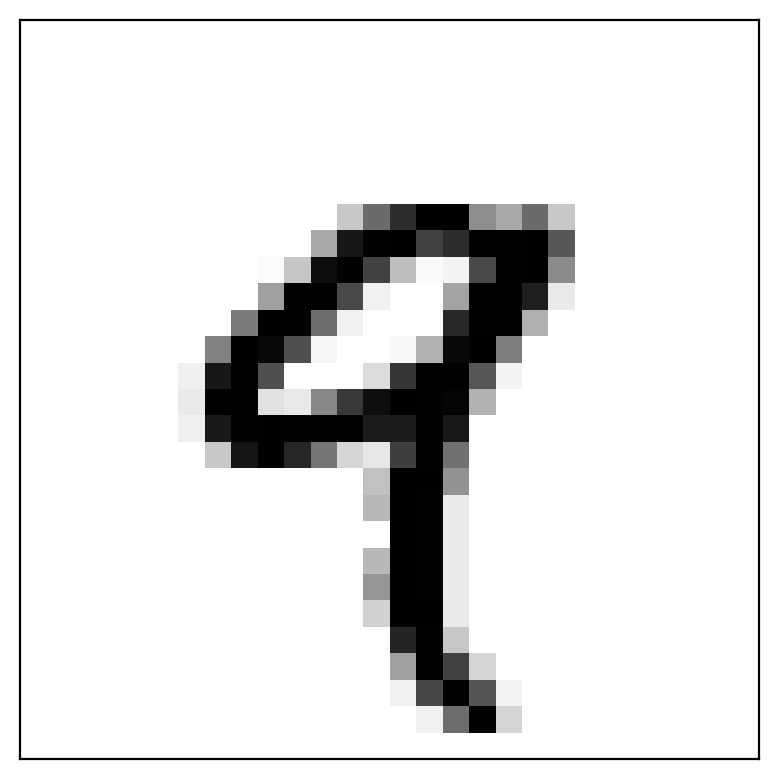

In [3]:
def display_image(im):
    plt.imshow(im.squeeze(), cmap='gray_r')
    plt.xticks([])
    plt.yticks([])

display_image(train_ds[4][0])


## Multilayer convolutional network
Convolutional nets replace early fully connected layers with local convolutions and pooling. Inputs are 4D tensors `(batch, channels, height, width)`; here `channels=1` for grayscale MNIST. Convolutions learn spatial filters, ReLU keeps positive activations, and pooling downsamples to make features more translation-robust before a dense head.


# CNN model
We stack convolution + ReLU + pooling blocks to extract spatial features before a fully connected head. Convolutions learn local patterns with shared weights; ReLU keeps computation simple and sparse; max pooling downsamples while keeping strongest activations.


In [4]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
        self.pool2 = nn.MaxPool2d(2)
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(64 * 4 * 4, 1024)
        self.drop = nn.Dropout(0.5)
        self.linear2 = nn.Linear(1024, ncats)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.flatten(x)
        x = F.relu(self.linear1(x))
        x = self.drop(x)
        return self.linear2(x)  # logits

model = CNN().to(device)


## Layer shapes and operations
- `Conv2d(1, 32, 5)`: 32 filters over 5x5 patches; ReLU keeps positive activations.
- `MaxPool2d(2)`: downsamples by 2 to reduce spatial size and add translation robustness.
- `Conv2d(32, 64, 5)` + `MaxPool2d(2)`: repeat with more channels; after two pools, 28x28 becomes 4x4 maps.
- Flatten -> `Linear(64*4*4, 1024)` -> ReLU -> `Dropout(0.5)` -> `Linear(1024, 10)` logits.


# Training helpers
Same helpers as in T_FFN: manual train/eval loops and accuracy metric.


In [5]:
def accuracy(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).float().mean().item()


def train_one_batch(model, xb, yb, optimizer, loss_fn):
    model.train()
    xb, yb = xb.to(device), yb.to(device)
    optimizer.zero_grad()
    logits = model(xb)
    loss = loss_fn(logits, yb)
    loss.backward()
    optimizer.step()
    return loss.item(), accuracy(logits, yb)


def evaluate(model, loader, loss_fn):
    model.eval()
    running_loss, running_acc, batches = 0.0, 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            running_loss += loss.item()
            running_acc += accuracy(logits, yb)
            batches += 1
    return running_loss / batches, running_acc / batches

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())


# Train the model
We log metrics once per epoch; Epoch 00 reflects the untrained model.


Epoch 00: train_acc=0.054, val_acc=0.054


Epoch 01: train_acc=0.987, val_acc=0.987


Epoch 02: train_acc=0.992, val_acc=0.987


Epoch 03: train_acc=0.995, val_acc=0.991


Epoch 04: train_acc=0.996, val_acc=0.991


...

Epoch 16: train_acc=0.999, val_acc=0.992


Epoch 17: train_acc=0.999, val_acc=0.991


Epoch 18: train_acc=0.999, val_acc=0.991


Epoch 19: train_acc=0.999, val_acc=0.991


Epoch 20: train_acc=1.000, val_acc=0.993


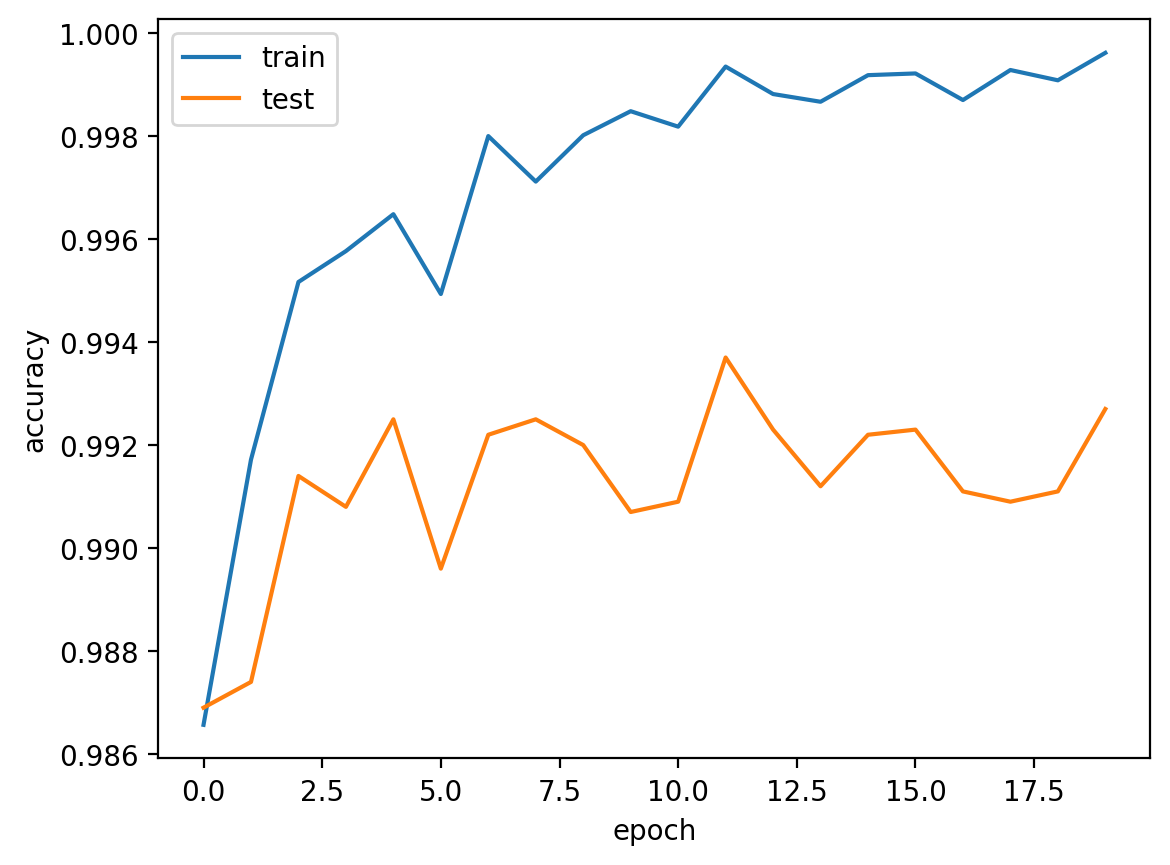

In [6]:
metrics = {"train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}
epochs = 20

train_loss, train_acc = evaluate(model, train_loader, loss_fn)
val_loss, val_acc = evaluate(model, test_loader, loss_fn)
metrics["train_loss"].append(train_loss)
metrics["train_accuracy"].append(train_acc)
metrics["val_loss"].append(val_loss)
metrics["val_accuracy"].append(val_acc)
print(f"Epoch 00: train_acc={train_acc:.3f}, val_acc={val_acc:.3f}")

for epoch in range(epochs):
    for xb, yb in train_loader:
        train_one_batch(model, xb, yb, optimizer, loss_fn)
    train_loss, train_acc = evaluate(model, train_loader, loss_fn)
    val_loss, val_acc = evaluate(model, test_loader, loss_fn)
    metrics["train_loss"].append(train_loss)
    metrics["train_accuracy"].append(train_acc)
    metrics["val_loss"].append(val_loss)
    metrics["val_accuracy"].append(val_acc)
    print(f"Epoch {epoch+1:02d}: train_acc={train_acc:.3f}, val_acc={val_acc:.3f}")

plt.plot(metrics['train_accuracy'][1:], label='train')
plt.plot(metrics['val_accuracy'][1:], label='test')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend();


Save the model and training history:


In [7]:
torch.save(model.state_dict(), "../data/torch_cnn_state.pt")
torch.save(metrics, "../data/torch_cnn_history.pt")


Load the model and history:


In [8]:
model = CNN().to(device)
model.load_state_dict(torch.load("../data/torch_cnn_state.pt", map_location=device))
metrics = torch.load("../data/torch_cnn_history.pt")


Predict on a test image:


Truth: 7, Prediction: 7 (1.0000)


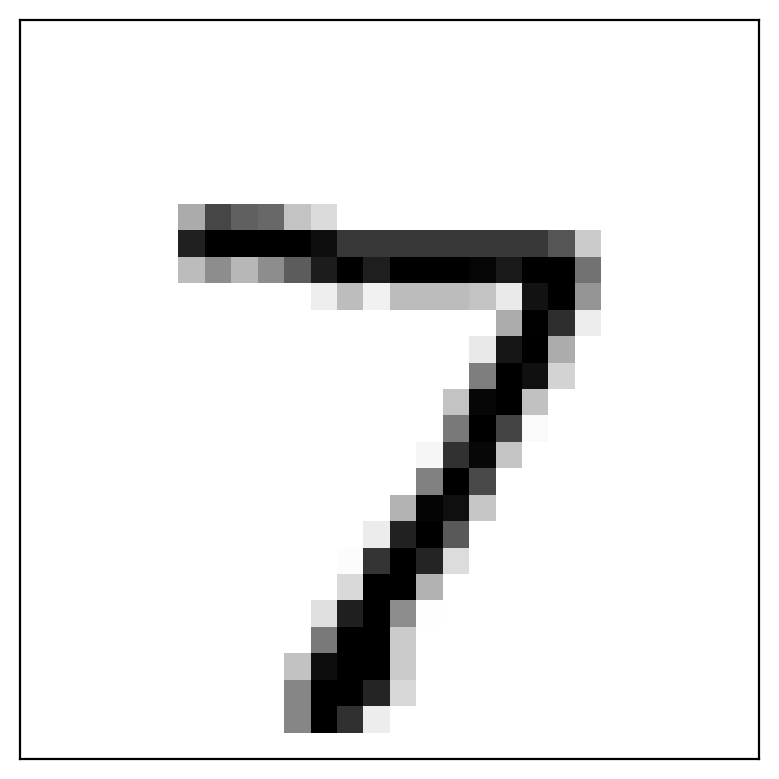

In [9]:
model.eval()
im, label = test_ds[0]
with torch.no_grad():
    logits = model(im.unsqueeze(0).to(device))
    probs = torch.softmax(logits, dim=1).cpu().squeeze()
print(f"Truth: {label}, Prediction: {probs.argmax().item()} ({probs.max():.4f})")
display_image(im)


# References
- PyTorch docs: https://pytorch.org
- TorchVision docs: https://pytorch.org/vision/stable/index.html
- Stanford CS231n notes: https://cs231n.github.io/convolutional-networks/


# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).
This work is licensed under a CC BY-NC-SA 4.0 International License.
![Python logo](../logo.png)
